# 🧠 Notebook 03: State & Memory — Long-Running Investigations

This notebook demonstrates long-running SOC investigation memory using Microsoft Foundry Responses API. We investigate a phishing-led incident across multiple turns, preserve context with `previous_response_id`, maintain an explicit audit trail, and resume a conversation across sessions with a new agent version.

In [13]:
import sys, os, json
sys.path.insert(0, os.path.abspath("../src"))
import nest_asyncio; nest_asyncio.apply()
from soc_workshop.settings import get_settings
from soc_workshop.clients import get_project_client, configure_tracing
from soc_workshop.incident_schema import Alert, TimelineEvent, InvestigationRecord
from soc_workshop.tools.sentinel_mock import get_alert_details, get_related_alerts, get_sign_in_logs
from azure.ai.projects.models import PromptAgentDefinition, FunctionTool
from openai.types.responses.response_input_param import FunctionCallOutput
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from IPython.display import display, Markdown

settings = get_settings()
configure_tracing()
project_client = get_project_client(settings)
openai_client = project_client.get_openai_client()

## Part 1: First Investigation Turn

In [14]:
tools = [
    FunctionTool(
        name="get_alert_details",
        description="Return full details for a Sentinel alert by ID.",
        parameters={
            "type": "object",
            "properties": {
                "alert_id": {
                    "type": "string",
                    "description": "The alert ID"
                }
            },
            "required": ["alert_id"],
            "additionalProperties": False
        },
        strict=True,
    ),
    FunctionTool(
        name="get_related_alerts",
        description="Find alerts sharing an entity value (IP, user, host, hash).",
        parameters={
            "type": "object",
            "properties": {
                "entity_value": {
                    "type": "string",
                    "description": "Entity value to pivot on"
                }
            },
            "required": ["entity_value"],
            "additionalProperties": False
        },
        strict=True,
    ),
    FunctionTool(
        name="get_sign_in_logs",
        description="Retrieve recent sign-in activity for a user principal.",
        parameters={
            "type": "object",
            "properties": {
                "user_principal": {
                    "type": "string",
                    "description": "User principal name"
                }
            },
            "required": ["user_principal"],
            "additionalProperties": False
        },
        strict=True,
    ),
]

TOOL_DISPATCH = {
    "get_alert_details": get_alert_details,
    "get_related_alerts": get_related_alerts,
    "get_sign_in_logs": get_sign_in_logs,
}


def run_agent_with_tools(openai_client, agent, user_input, tool_dispatch, max_rounds=10, previous_response_id=None):
    kwargs = {
        "input": user_input,
        "model": settings.model_deployment,
        "extra_body": {"agent_reference": {"name": agent.name, "type": "agent_reference"}},
    }
    if previous_response_id:
        kwargs["previous_response_id"] = previous_response_id
    response = openai_client.responses.create(**kwargs)

    for _ in range(max_rounds):
        fn_calls = [item for item in response.output if item.type == "function_call"]
        if not fn_calls:
            break
        fn_outputs = []
        for call in fn_calls:
            fn = tool_dispatch.get(call.name)
            if fn is None:
                result = json.dumps({"error": f"Unknown: {call.name}"})
            else:
                args = json.loads(call.arguments)
                result = fn(**args)
            fn_outputs.append(FunctionCallOutput(type="function_call_output", call_id=call.call_id, output=result))
        response = openai_client.responses.create(
            input=fn_outputs,
            previous_response_id=response.id,
            extra_body={"agent_reference": {"name": agent.name, "type": "agent_reference"}},
        )
    return response

conversation_log = []
response_chain = []

In [15]:
agent = project_client.agents.create_version(
    agent_name="soc-investigator-memory",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=(
            "You are a SOC incident investigator. Correlate alerts, infer attack progression, and"
            " update confidence as new evidence arrives. Use available tools before concluding."
            " Keep output concise with sections: Findings, Correlation, Risk, Next Actions."
        ),
        tools=tools,
    ),
)

print(f"Created investigation agent: {agent.name} v{agent.version}")

Created investigation agent: soc-investigator-memory v3


In [16]:
prompt_1 = (
    "Start an investigation for ALERT-2025-004 (phishing). Use tools to summarize evidence,"
    " likely impact, and immediate containment actions."
)

response_1 = run_agent_with_tools(
    openai_client=openai_client,
    agent=agent,
    user_input=prompt_1,
    tool_dispatch=TOOL_DISPATCH,
)

conversation_log.append({"turn": 1, "role": "user", "content": prompt_1})
conversation_log.append({"turn": 1, "role": "assistant", "content": response_1.output_text})
response_chain.append({"part": "Part 1", "response_id": response_1.id})

display(Markdown("### Agent Response (Initial Phishing Investigation)"))
display(Markdown(response_1.output_text))
print(f"response_1.id = {response_1.id}")

### Agent Response (Initial Phishing Investigation)

**Findings:**  
- Alert: Phishing email targeting jdoe@contoso.com with a malicious credential harvesting link.
- Entity: jdoe@contoso.com (Finance team) is linked to multiple severe alerts: suspicious PowerShell, TOR-based sign-in, mass file encryption, and data exfiltration.
- Recent sign-in activity reveals a successful login from a TOR exit node (high risk, no MFA, unknown device) before this phishing incident.

**Correlation:**  
- The phishing email likely led to credential compromise.
- The compromised credentials were used for anomalous, high-risk access from an external TOR node.
- Follow-on activity includes evidence of potential execution (PowerShell), ransomware (file encryption), and data theft (exfiltration).

**Risk:**  
- Attack progression suggests initial access, credential compromise, privilege escalation, data theft, and potential ransomware.
- High-impact scenario involving sensitive finance personnel.

**Next Actions:**  
1. Immediately reset jdoe@contoso.com credentials, enforce MFA.
2. Disable access for jdoe@contoso.com pending investigation.
3. Block suspicious domains and URLs (contos0-login.evil.com).
4. Initiate device and network forensics on WKS-FIN-PC04, TOR-sourced connections, and cloud storage exfiltration.
5. Notify affected teams (Finance, IT) and escalate incident response.

response_1.id = resp_04f6ef7f8b2c8a520069adf54dc05c8190ba389f6ac1eec8ab


## Part 2: Resuming — New Evidence

In [17]:
prompt_2 = (
    "New evidence: ALERT-2025-002 indicates anomalous TOR sign-in for jdoe@contoso.com."
    " Correlate it with the earlier phishing alert and update risk/confidence."
)

response_2 = run_agent_with_tools(
    openai_client=openai_client,
    agent=agent,
    user_input=prompt_2,
    tool_dispatch=TOOL_DISPATCH,
    previous_response_id=response_1.id,
)

conversation_log.append({"turn": 2, "role": "user", "content": prompt_2})
conversation_log.append({"turn": 2, "role": "assistant", "content": response_2.output_text})
response_chain.append({"part": "Part 2", "response_id": response_2.id})

display(Markdown("### Agent Response (Phishing + TOR Correlation)"))
display(Markdown(response_2.output_text))
print(f"response_2.id = {response_2.id}; previous_response_id used = {response_1.id}")

### Agent Response (Phishing + TOR Correlation)

**Findings:**  
- ALERT-2025-002: jdoe@contoso.com authenticated from a TOR exit node (IP: 185.220.101.42), outside business hours, on an unknown/non-compliant device, no MFA.
- ALERT-2025-004: Phishing email targeted jdoe@contoso.com, contained a fake login portal link.

**Correlation:**  
- Phishing email likely enabled credential theft.
- Stolen credentials used for immediate, anomalous access via TOR (known tactic for adversaries to mask origin).
- Sign-in timing and method are highly suspect and reinforce direct linkage between phishing and credential misuse.

**Risk & Confidence Update:**  
- Risk is now confirmed as high for jdoe@contoso.com and associated assets.
- Confidence is strong that compromise originated from phishing, followed by credential abuse.
- Attack progression visible: Initial Access (phishing) > Exploitation (TOR sign-in).

**Next Actions:**  
1. Maintain previous containment actions: forced credential reset, MFA enforcement, account disabling.
2. Expand investigation into other possible impacted accounts using the TOR IP and phishing domain.
3. Enhance monitoring for TOR/IP-based access attempts across environment.
4. Expedite finance team notification and process review for sensitive operations and potential fraud.

response_2.id = resp_04f6ef7f8b2c8a520069adf55167a48190a1fc259cf7260773; previous_response_id used = resp_04f6ef7f8b2c8a520069adf54dc05c8190ba389f6ac1eec8ab


## Part 3: Evidence Escalation

In [18]:
prompt_3 = (
    "Add ALERT-2025-001 (Cobalt Strike activity). Connect phishing -> credential theft ->"
    " malware execution. Update confidence and priority actions."
)

response_3 = run_agent_with_tools(
    openai_client=openai_client,
    agent=agent,
    user_input=prompt_3,
    tool_dispatch=TOOL_DISPATCH,
    previous_response_id=response_2.id,
)

conversation_log.append({"turn": 3, "role": "user", "content": prompt_3})
conversation_log.append({"turn": 3, "role": "assistant", "content": response_3.output_text})
response_chain.append({"part": "Part 3A", "response_id": response_3.id})

prompt_4 = (
    "Now provide a consolidated timeline with key timestamps, entities, and confidence progression"
    " across all evidence so far."
)

response_4 = run_agent_with_tools(
    openai_client=openai_client,
    agent=agent,
    user_input=prompt_4,
    tool_dispatch=TOOL_DISPATCH,
    previous_response_id=response_3.id,
)

conversation_log.append({"turn": 4, "role": "user", "content": prompt_4})
conversation_log.append({"turn": 4, "role": "assistant", "content": response_4.output_text})
response_chain.append({"part": "Part 3B", "response_id": response_4.id})

display(Markdown("### Agent Response (Expanded Attack Chain)"))
display(Markdown(response_3.output_text))
display(Markdown("### Agent Consolidated Timeline"))
display(Markdown(response_4.output_text))

### Agent Response (Expanded Attack Chain)

**Findings:**  
- ALERT-2025-001: WKS-FIN-PC04 (finance team) executed a suspicious, encoded PowerShell command, downloading a Cobalt Strike payload from known C2 infrastructure (198.51.100.23).
- jdoe@contoso.com is tied to this device and activity, with file evidence of a Cobalt Strike beacon.

**Correlation:**  
- Phishing (ALERT-2025-004) → Anomalous TOR sign-in (ALERT-2025-002) → Credential theft enabled attacker access.
- Compromised credentials led to malware delivery and execution (ALERT-2025-001).
- Clear attacker progression: Initial Access (phishing), Credential Abuse (TOR sign-in), Malware Execution (Cobalt Strike), likely lateral movement and additional actions (ransomware/exfiltration per prior related alerts).

**Risk & Confidence Update:**  
- Attack confirmed: Confidence is extremely high; priority is critical.
- Systemic compromise of finance assets and clear C2 interaction.

**Priority Actions:**  
1. Isolate WKS-FIN-PC04 immediately and scan for Cobalt Strike and ransomware artifacts.
2. Review firewall, proxy, and endpoint logs for traffic to known C2 (198.51.100.23).
3. Accelerate credential reset, MFA enforcement, and access disablement for jdoe and any affected finance team assets.
4. Hunt for lateral movement across finance and network shares; validate file encryption/exfiltration alerts.
5. Prepare full incident escalation for containment, eradication, and forensic investigation.

### Agent Consolidated Timeline

**Consolidated Incident Timeline**

| Timestamp               | Event                                              | Entity/Asset              | Confidence | Notes                                    |
|-------------------------|----------------------------------------------------|---------------------------|------------|-------------------------------------------|
| 2025-03-06 17:45:00     | Normal sign-in to SharePoint Online                | jdoe@contoso.com / WKS-FIN-PC04 | Low        | Baseline: Legitimate activity             |
| 2025-03-07 03:18:45     | Anomalous sign-in from TOR exit node               | jdoe@contoso.com, 185.220.101.42 | Moderate   | High risk; likely attack vector           |
| 2025-03-07 08:22:10     | Normal sign-in from compliant device               | jdoe@contoso.com / WKS-FIN-PC04 | Low        | No risk; typical                  |
| 2025-03-07 09:45:00     | Receipt of credential harvesting phishing email    | jdoe@contoso.com, hr-benefits@contos0.com | Moderate   | Potential compromise; phishing initiated  |
| 2025-03-07 09:50:12     | Failed sign-in from suspicious geo (Nigeria)       | jdoe@contoso.com, 203.0.113.77  | Moderate   | Suspicious activity post-phish            |
| 2025-03-07 14:32:11     | Cobalt Strike activity via PowerShell              | WKS-FIN-PC04, 198.51.100.23, filehash | High       | Malware execution confirms compromise      |

**Entities Involved:**  
- User: jdoe@contoso.com (Finance team)
- Device: WKS-FIN-PC04
- IPs: 185.220.101.42 (TOR), 198.51.100.23 (C2), 203.0.113.77 (Suspicious geo)
- Phishing domain: contos0-login.evil.com

**Confidence Progression:**
- Starts moderate at phishing email, increases with TOR sign-in, turns high after Cobalt Strike stager execution is confirmed—demonstrates attacker’s full chain from initial access to C2/malware.

**Summary:**  
- The timeline documents a clear attacker journey: phishing → credentials compromised → illicit access → malware deployment, progressing risk and confidence with each step. Immediate containment and escalation are justified.

## Part 4: Conversation Audit Trail

In [19]:
conversation_df = pd.DataFrame(conversation_log)
conversation_df["logged_at_utc"] = datetime.utcnow().isoformat() + "Z"
conversation_df["preview"] = conversation_df["content"].str.slice(0, 220)

display(Markdown("Responses API does not expose `messages.list`; we track our own `conversation_log`."))
display(conversation_df[["turn", "role", "logged_at_utc", "preview"]])

response_chain_df = pd.DataFrame(response_chain)
display(response_chain_df)

C:\Users\haozhang2\AppData\Local\Temp\ipykernel_5972\1130759514.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  conversation_df["logged_at_utc"] = datetime.utcnow().isoformat() + "Z"


Responses API does not expose `messages.list`; we track our own `conversation_log`.

,turn,role,logged_at_utc,preview
0,1,user,2026-03-08T22:17:01.048984Z,Start an investigation for ALERT-2025-004 (phi...
1,1,assistant,2026-03-08T22:17:01.048984Z,**Findings:** \n- Alert: Phishing email targe...
2,2,user,2026-03-08T22:17:01.048984Z,New evidence: ALERT-2025-002 indicates anomalo...
3,2,assistant,2026-03-08T22:17:01.048984Z,**Findings:** \n- ALERT-2025-002: jdoe@contos...
4,3,user,2026-03-08T22:17:01.048984Z,Add ALERT-2025-001 (Cobalt Strike activity). C...
5,3,assistant,2026-03-08T22:17:01.048984Z,**Findings:** \n- ALERT-2025-001: WKS-FIN-PC0...
6,4,user,2026-03-08T22:17:01.048984Z,Now provide a consolidated timeline with key t...
7,4,assistant,2026-03-08T22:17:01.048984Z,**Consolidated Incident Timeline**\n\n| Timest...


,part,response_id
0,Part 1,resp_04f6ef7f8b2c8a520069adf54dc05c8190ba389f6...
1,Part 2,resp_04f6ef7f8b2c8a520069adf55167a48190a1fc259...
2,Part 3A,resp_04f6ef7f8b2c8a520069adf555b0c08190abae899...
3,Part 3B,resp_04f6ef7f8b2c8a520069adf558fc9081908e7c924...


In [20]:
core_alert_ids = ["ALERT-2025-004", "ALERT-2025-002", "ALERT-2025-001", "ALERT-2025-003"]
alert_docs = [json.loads(get_alert_details(aid)) for aid in core_alert_ids]

analysis_points = [
    {"event": "Initial agent analysis", "timestamp": datetime.utcnow().isoformat() + "Z", "severity": "analysis", "kind": "Agent analysis"},
    {"event": "Correlation update", "timestamp": datetime.utcnow().isoformat() + "Z", "severity": "analysis", "kind": "Agent analysis"},
    {"event": "Escalation reasoning", "timestamp": datetime.utcnow().isoformat() + "Z", "severity": "analysis", "kind": "Agent analysis"},
]

timeline_rows = [
    {
        "event": f"{a['alert_id']} - {a['title']}",
        "timestamp": a["timestamp"],
        "severity": a["severity"],
        "kind": "Alert"
    }
    for a in alert_docs
] + analysis_points

timeline_df = pd.DataFrame(timeline_rows)
timeline_df["timestamp"] = pd.to_datetime(timeline_df["timestamp"], utc=True, errors="coerce")
timeline_df = timeline_df.sort_values("timestamp").reset_index(drop=True)
display(timeline_df)

C:\Users\haozhang2\AppData\Local\Temp\ipykernel_5972\890997050.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  {"event": "Initial agent analysis", "timestamp": datetime.utcnow().isoformat() + "Z", "severity": "analysis", "kind": "Agent analysis"},
C:\Users\haozhang2\AppData\Local\Temp\ipykernel_5972\890997050.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  {"event": "Correlation update", "timestamp": datetime.utcnow().isoformat() + "Z", "severity": "analysis", "kind": "Agent analysis"},
C:\Users\haozhang2\AppData\Local\Temp\ipykernel_5972\890997050.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use t

,event,timestamp,severity,kind
0,ALERT-2025-002 - Anomalous sign-in from TOR ex...,2025-03-07 03:18:45+00:00,High,Alert
1,ALERT-2025-004 - Credential harvesting phishin...,2025-03-07 09:45:00+00:00,Medium,Alert
2,ALERT-2025-001 - Suspicious PowerShell executi...,2025-03-07 14:32:11+00:00,High,Alert
3,ALERT-2025-003 - Mass file encryption detected...,2025-03-07 15:01:33+00:00,Critical,Alert
4,Initial agent analysis,NaT,analysis,Agent analysis
5,Correlation update,NaT,analysis,Agent analysis
6,Escalation reasoning,NaT,analysis,Agent analysis


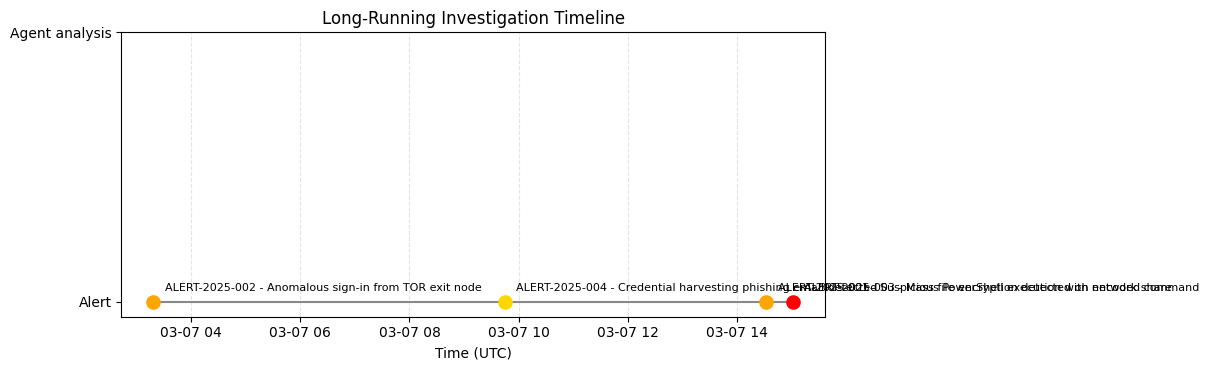

In [21]:
severity_colors = {
    "Critical": "red",
    "High": "orange",
    "Medium": "gold",
    "analysis": "green"
}

y_map = {"Alert": 0, "Agent analysis": 1}

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.hlines(y=0, xmin=timeline_df["timestamp"].min(), xmax=timeline_df["timestamp"].max(), colors="#888", linewidth=1.5)

for _, row in timeline_df.iterrows():
    color = severity_colors.get(row["severity"], "gray")
    y = y_map.get(row["kind"], 0)
    ax.scatter(row["timestamp"], y, color=color, s=90, zorder=3)
    ax.annotate(row["event"], (row["timestamp"], y), xytext=(8, 8), textcoords="offset points", fontsize=8)

ax.set_yticks([0, 1])
ax.set_yticklabels(["Alert", "Agent analysis"])
ax.set_title("Long-Running Investigation Timeline")
ax.set_xlabel("Time (UTC)")
ax.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

In [22]:
entities = sorted({e["value"] for a in alert_docs for e in a.get("entities", [])})
confidence_progression = pd.DataFrame([
    {"phase": "After phishing", "confidence": 0.35},
    {"phase": "After TOR sign-in", "confidence": 0.55},
    {"phase": "After Cobalt Strike", "confidence": 0.78},
    {"phase": "After ransomware", "confidence": 0.93},
])

investigation_stats = pd.DataFrame([
    {
        "alerts_correlated": len(alert_docs),
        "entities_involved": len(entities),
        "conversation_turns_logged": int(conversation_df["turn"].max()) if not conversation_df.empty else 0,
        "current_confidence": confidence_progression["confidence"].iloc[-1],
        "latest_response_id": response_4.id
    }
])

display(investigation_stats)
display(confidence_progression)

,alerts_correlated,entities_involved,conversation_turns_logged,current_confidence,latest_response_id
0,4,8,4,0.93,resp_04f6ef7f8b2c8a520069adf558fc9081908e7c924...


,phase,confidence
0,After phishing,0.35
1,After TOR sign-in,0.55
2,After Cobalt Strike,0.78
3,After ransomware,0.93


## Part 5: Cross-Session Resumption

In [23]:
def run_conversation_with_tools(openai_client, conversation_id, agent_name, tool_dispatch, max_rounds=10):
    """Create a response in a conversation and resolve any tool calls."""
    response = openai_client.responses.create(
        conversation=conversation_id,
        extra_body={"agent_reference": {"name": agent_name, "type": "agent_reference"}},
    )
    for _ in range(max_rounds):
        fn_calls = [item for item in response.output if item.type == "function_call"]
        if not fn_calls:
            break
        fn_outputs = []
        for call in fn_calls:
            fn = tool_dispatch.get(call.name)
            if fn is None:
                result = json.dumps({"error": f"Unknown: {call.name}"})
            else:
                args = json.loads(call.arguments)
                result = fn(**args)
            fn_outputs.append(FunctionCallOutput(type="function_call_output", call_id=call.call_id, output=result))
        response = openai_client.responses.create(
            conversation=conversation_id,
            input=fn_outputs,
            extra_body={"agent_reference": {"name": agent_name, "type": "agent_reference"}},
        )
    return response

resumed_agent = project_client.agents.create_version(
    agent_name=agent.name,
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=(
            "You are resuming an active SOC incident from existing conversation context."
            " Add only net-new analysis and updated containment priorities."
        ),
        tools=tools,
    ),
)

conversation = openai_client.conversations.create(
    items=[{
        "type": "message",
        "role": "user",
        "content": "Seed context: investigate ALERT-2025-004 and ALERT-2025-002 linkage for jdoe@contoso.com."
    }],
)

conv_response_1 = run_conversation_with_tools(
    openai_client, conversation.id, agent.name, TOOL_DISPATCH
)

openai_client.conversations.items.create(
    conversation_id=conversation.id,
    items=[{
        "type": "message",
        "role": "user",
        "content": "New evidence: ALERT-2025-003 ransomware encryption detected. Re-assess scope and top containment actions."
    }],
)

conv_response_2 = run_conversation_with_tools(
    openai_client, conversation.id, resumed_agent.name, TOOL_DISPATCH
)

display(Markdown("### Conversation Response (Original Agent Version)"))
display(Markdown(conv_response_1.output_text))
display(Markdown("### Conversation Response (New Agent Version, Same Conversation)"))
display(Markdown(conv_response_2.output_text))

cross_session_df = pd.DataFrame([
    {
        "conversation_id": conversation.id,
        "response_id": conv_response_1.id,
        "agent_name": agent.name,
        "agent_version": agent.version,
        "note": "Initial response in persisted conversation"
    },
    {
        "conversation_id": conversation.id,
        "response_id": conv_response_2.id,
        "agent_name": resumed_agent.name,
        "agent_version": resumed_agent.version,
        "note": "Resumed with new agent version; conversation state persisted"
    }
])
display(cross_session_df)

### Conversation Response (Original Agent Version)

**Net-New Analysis:**
- The phishing email (ALERT-2025-004) targeting jdoe@contoso.com arrived ~6 hours after an anomalous TOR-based sign-in (ALERT-2025-002); this sequence suggests the phishing campaign may have directly led to credential compromise.
- jdoe@contoso.com is linked to several additional high-severity alerts, including suspicious PowerShell execution (ALERT-2025-001), mass file encryption (ALERT-2025-003), and data exfiltration (ALERT-2025-006), indicating escalation beyond initial access.
- Sign-in logs show a high-risk, successful authentication via TOR at 03:18, followed later by legitimate activity from jdoe’s compliant device (08:22). The timeline implies attacker access was distinct and likely undetected by the user.
- Failed sign-in from Lagos, Nigeria (09:50), post-phishing, reinforces active attempts to use compromised credentials globally.

**Updated Containment Priorities:**
1. **Immediate remediation of jdoe@contoso.com** (account lock, credential reset, forced log-out from all sessions).
2. Investigate and isolate devices linked to suspicious activity (WKS-FIN-PC04 for lateral movement, any detected “unknown devices”).
3. Block and monitor TOR exit IPs (e.g., 185.220.101.42) and phishing domain (contos0-login.evil.com).
4. Review and halt automated actions (PowerShell scripts, mass network encryption, data exfiltration) tied to this user context.
5. Full audit of finance-team accounts; attacker may pivot or harvest privilege via intra-team access.

**Ongoing Priorities:**  
- Forensic review of impacted endpoints and network shares; preserve evidence from mass file encryption (ALERT-2025-003).
- Confirm containment of any exfiltration channels (cloud storage, email, SharePoint).
- Initiate enterprise-wide phishing awareness and credential hygiene review.

**Next Steps:**  
Would you like a prioritized checklist or escalation report for incident handling teams?

### Conversation Response (New Agent Version, Same Conversation)

**Net-New Analysis (Ransomware Detection):**
- ALERT-2025-003 confirms mass file encryption ("ransomware encryption detected on network share") tied to user jdoe@contoso.com.
- This alert, combined with prior credential compromise (phishing and TOR-based sign-in), strongly indicates the attacker progressed from initial access to lateral movement and finally deployed ransomware across network shares.
- Escalation pattern: Phishing → Account Compromise → Suspicious PowerShell → Ransomware → Data Exfiltration.
- Given the ransomware detection, there is high risk of data loss, business disruption, and further exfiltration, likely impacting critical finance-related resources.

**Expanded Incident Scope:**
- Multiple stages: Initial access (phishing), credential abuse, malware execution, and ransomware observed—attacker likely has (or had) broad access to network shares and potentially additional accounts (finance-team).
- Potential Impact: Financial data, sensitive documents, business continuity, and regulatory exposure.

---

**Updated Top Containment Actions (Highest Priority):**

1. **Immediate Isolation of Affected Endpoints and Network Shares**
   - Disconnect compromised devices (especially WKS-FIN-PC04 and any hosts involved in PowerShell or encryption activity) from network to halt ransomware spread and preserve evidence.
   - Disable access to infected network shares for all users.

2. **Account Control & Credential Reset**
   - Force global sign-out and reset credentials for jdoe@contoso.com and all identified finance-team accounts.
   - Block unauthorized devices and suspicious IPs (TOR node, Lagos sign-ins).

3. **Halt Malicious Processes & Actions**
   - Terminate all suspicious PowerShell sessions and ransomware processes on identified hosts.
   - Stop data exfiltration tasks (e.g., cloud sync, email forwarding, unauthorized uploads).

4. **Activate Ransomware Response Plan**
   - Notify IT, legal, and business leadership per incident response playbooks.
   - Begin backup restoration readiness (ensure latest backups are offline and clean).

5. **Forensic Preservation**
   - Secure forensic images of compromised systems for investigation.
   - Document and preserve logs from sign-in activity, file changes, network traffic, and encryption triggers.

6. **Containment Monitoring**
   - Deploy enhanced threat monitoring on all finance-team devices and network shares.
   - Monitor for lateral movement, privilege escalation, and residual attacker activity.

---

**Next Steps:**  
- Do you want containment actions distributed to technical teams, or escalation for executive notification as well?  
- Should I identify further network or data assets likely impacted for follow-up investigation and recovery planning?

,conversation_id,response_id,agent_name,agent_version,note
0,conv_814a9fa2d70be6bf008OWD3wBPdMwmW4zQuiK0plK...,resp_814a9fa2d70be6bf0069adf55f702c81909cec3a3...,soc-investigator-memory,3,Initial response in persisted conversation
1,conv_814a9fa2d70be6bf008OWD3wBPdMwmW4zQuiK0plK...,resp_814a9fa2d70be6bf0069adf56341388190a121f7e...,soc-investigator-memory,4,Resumed with new agent version; conversation s...


In [24]:
timeline_records = [
    TimelineEvent(
        timestamp=row.timestamp.isoformat() if pd.notna(row.timestamp) else "",
        event=row.event,
        source=row.kind,
        severity=str(row.severity).lower(),
    )
    for row in timeline_df.itertuples(index=False)
]

record = InvestigationRecord(
    incident_id="INC-2025-03-07-03",
    title="Long-running phishing-to-ransomware investigation",
    alerts=[Alert.from_dict(a) for a in alert_docs],
    timeline=timeline_records,
    confidence=float(confidence_progression["confidence"].iloc[-1]),
    verdict="True Positive",
    hypothesis="Phishing-enabled credential theft progressed to endpoint compromise and ransomware impact.",
    recommended_actions=[
        "Isolate WKS-FIN-PC04 immediately",
        "Disable/reset impacted user and admin credentials",
        "Block C2/TOR infrastructure and enforce conditional access",
        "Start containment and recovery playbook for encrypted shares"
    ],
    thread_id=conversation.id,
    agent_ids=[f"{agent.name}:{agent.version}", f"{resumed_agent.name}:{resumed_agent.version}"],
)

with open("../data/investigation_03.json", "w", encoding="utf-8") as f:
    f.write(record.to_json(indent=2))

print("Saved ../data/investigation_03.json")

Saved ../data/investigation_03.json


### (optional) Cleanup

In [ ]:
# (optional) uncomment tocleanup - delete agent versions created in this notebook
# project_client.agents.delete_version(agent_name=agent.name, agent_version=agent.version)
# project_client.agents.delete_version(agent_name=resumed_agent.name, agent_version=resumed_agent.version)
# openai_client.close()
# print(f"Cleanup complete. Deleted agent versions: {agent.version}, {resumed_agent.version}")

Cleanup complete. Deleted agent versions: 3, 4


## Summary of this notebook
- Run a multi-turn investigation using Responses API with tool calls and previous_response_id chaining.
- Track conversation history, build a timeline, and visualize confidence progression.
- Resume across sessions with a new agent version and save investigation_03.json.

## What's Next

Continue to **Notebook 04** for orchestration patterns across broader SOC workflows.